**1**

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
from sqlalchemy import create_engine

from db_config import CONN_STR

engine = create_engine(CONN_STR)

# SQL-запит для об'єднання даних із таблиць main зони
query = """
SELECT 
    m.movie_id,
    m.title,
    m.genre,
    m.year,
    m.country,
    m.rating,
    m.runtime_minutes,
    m.budget,
    m.production_company,
    mp.average_rating,
    mp.number_of_votes,
    mp.approval_index,
    mp.production_budget,
    mp.worldwide_gross AS mp_worldwide_gross,
    mp.domestic_gross AS mp_domestic_gross,
    bo.worldwide AS bo_worldwide,
    bo.domestic AS bo_domestic,
    bo.foreign AS bo_foreign,
    bo.domestic_percent,
    bo.foreign_percent,
    d.name AS director_name,
    d.birth_year,
    d.professions,
    (SELECT COUNT(*) FROM main.movie_stars ms WHERE ms.movie_id = m.movie_id) AS stars_count,
    (SELECT COUNT(*) FROM main.movie_writers mw WHERE mw.movie_id = m.movie_id) AS writers_count,
    (SELECT COUNT(*) FROM main.fact_oscar_awards oa WHERE oa.movie_id = m.movie_id) AS nominations_count,
    (SELECT COUNT(*) FROM main.fact_oscar_awards oa WHERE oa.movie_id = m.movie_id AND oa.winner = TRUE) AS wins_count
FROM main.dim_movie m
LEFT JOIN main.fact_movie_performance mp ON m.movie_id = mp.movie_id
LEFT JOIN main.fact_box_office bo ON m.movie_id = bo.movie_id AND m.year = bo.year
LEFT JOIN main.dim_director d ON mp.director_id = d.director_id
"""

# Завантаження даних
df = pd.read_sql(query, engine)


Інформація про датафрейм:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7776 entries, 0 to 7775
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            7776 non-null   int64  
 1   title               7776 non-null   object 
 2   genre               7776 non-null   object 
 3   year                7776 non-null   int64  
 4   country             7775 non-null   object 
 5   rating              7700 non-null   object 
 6   runtime_minutes     7774 non-null   float64
 7   budget              5635 non-null   float64
 8   production_company  7761 non-null   object 
 9   average_rating      3636 non-null   float64
 10  number_of_votes     3636 non-null   float64
 11  approval_index      3636 non-null   float64
 12  production_budget   3636 non-null   float64
 13  mp_worldwide_gross  3636 non-null   float64
 14  mp_domestic_gross   3636 non-null   float64
 15  bo_worldwide        2582 non-

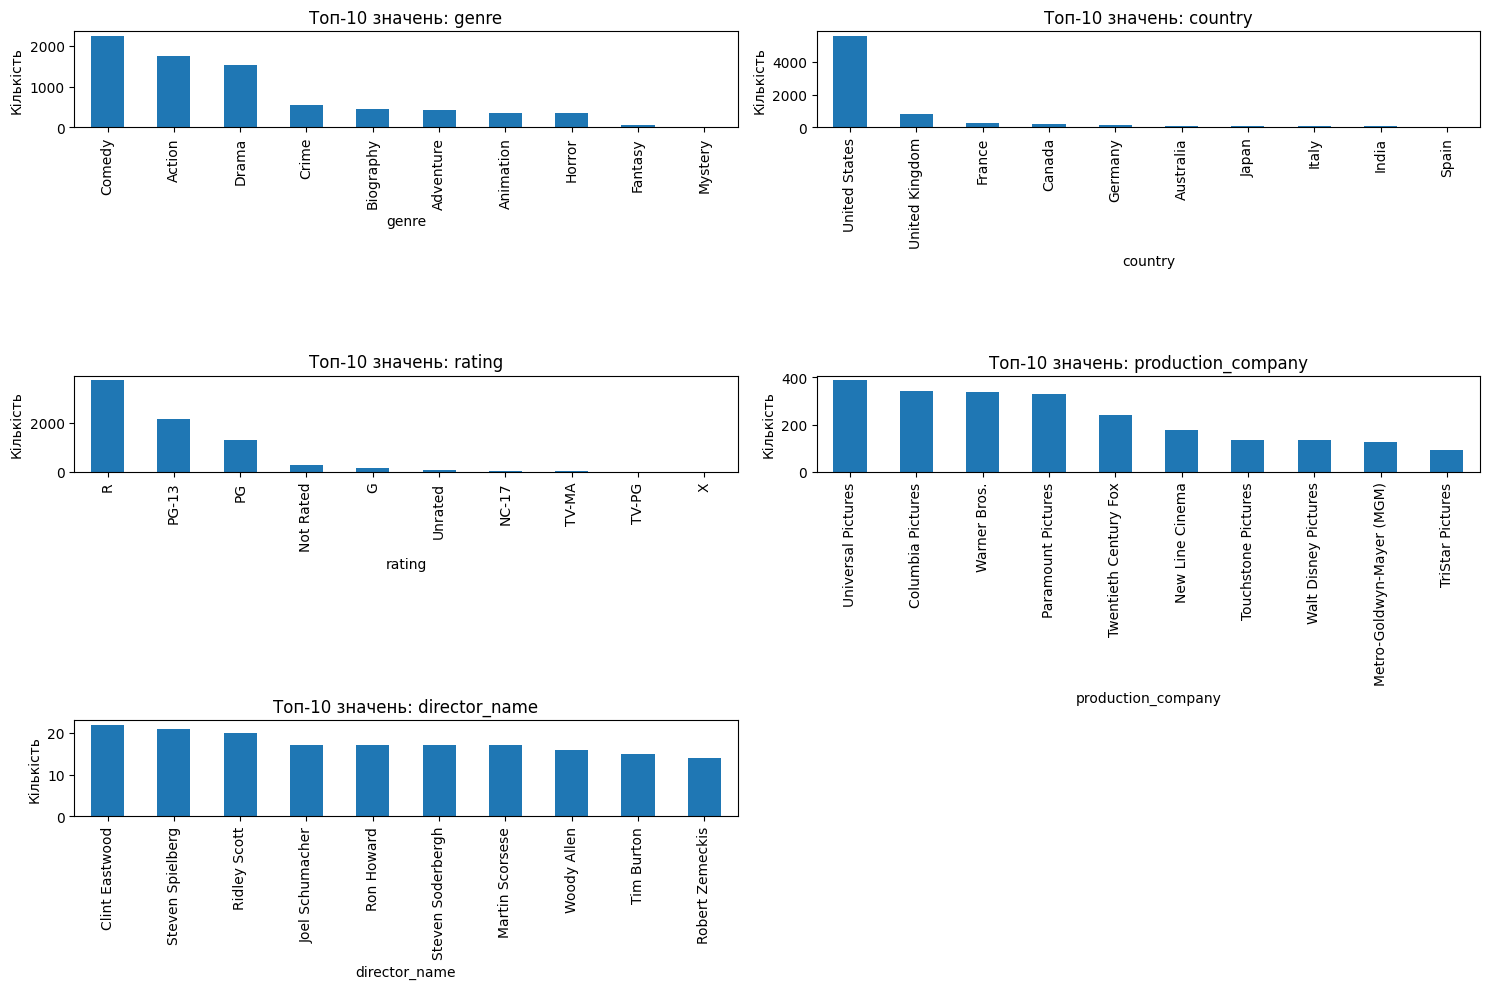

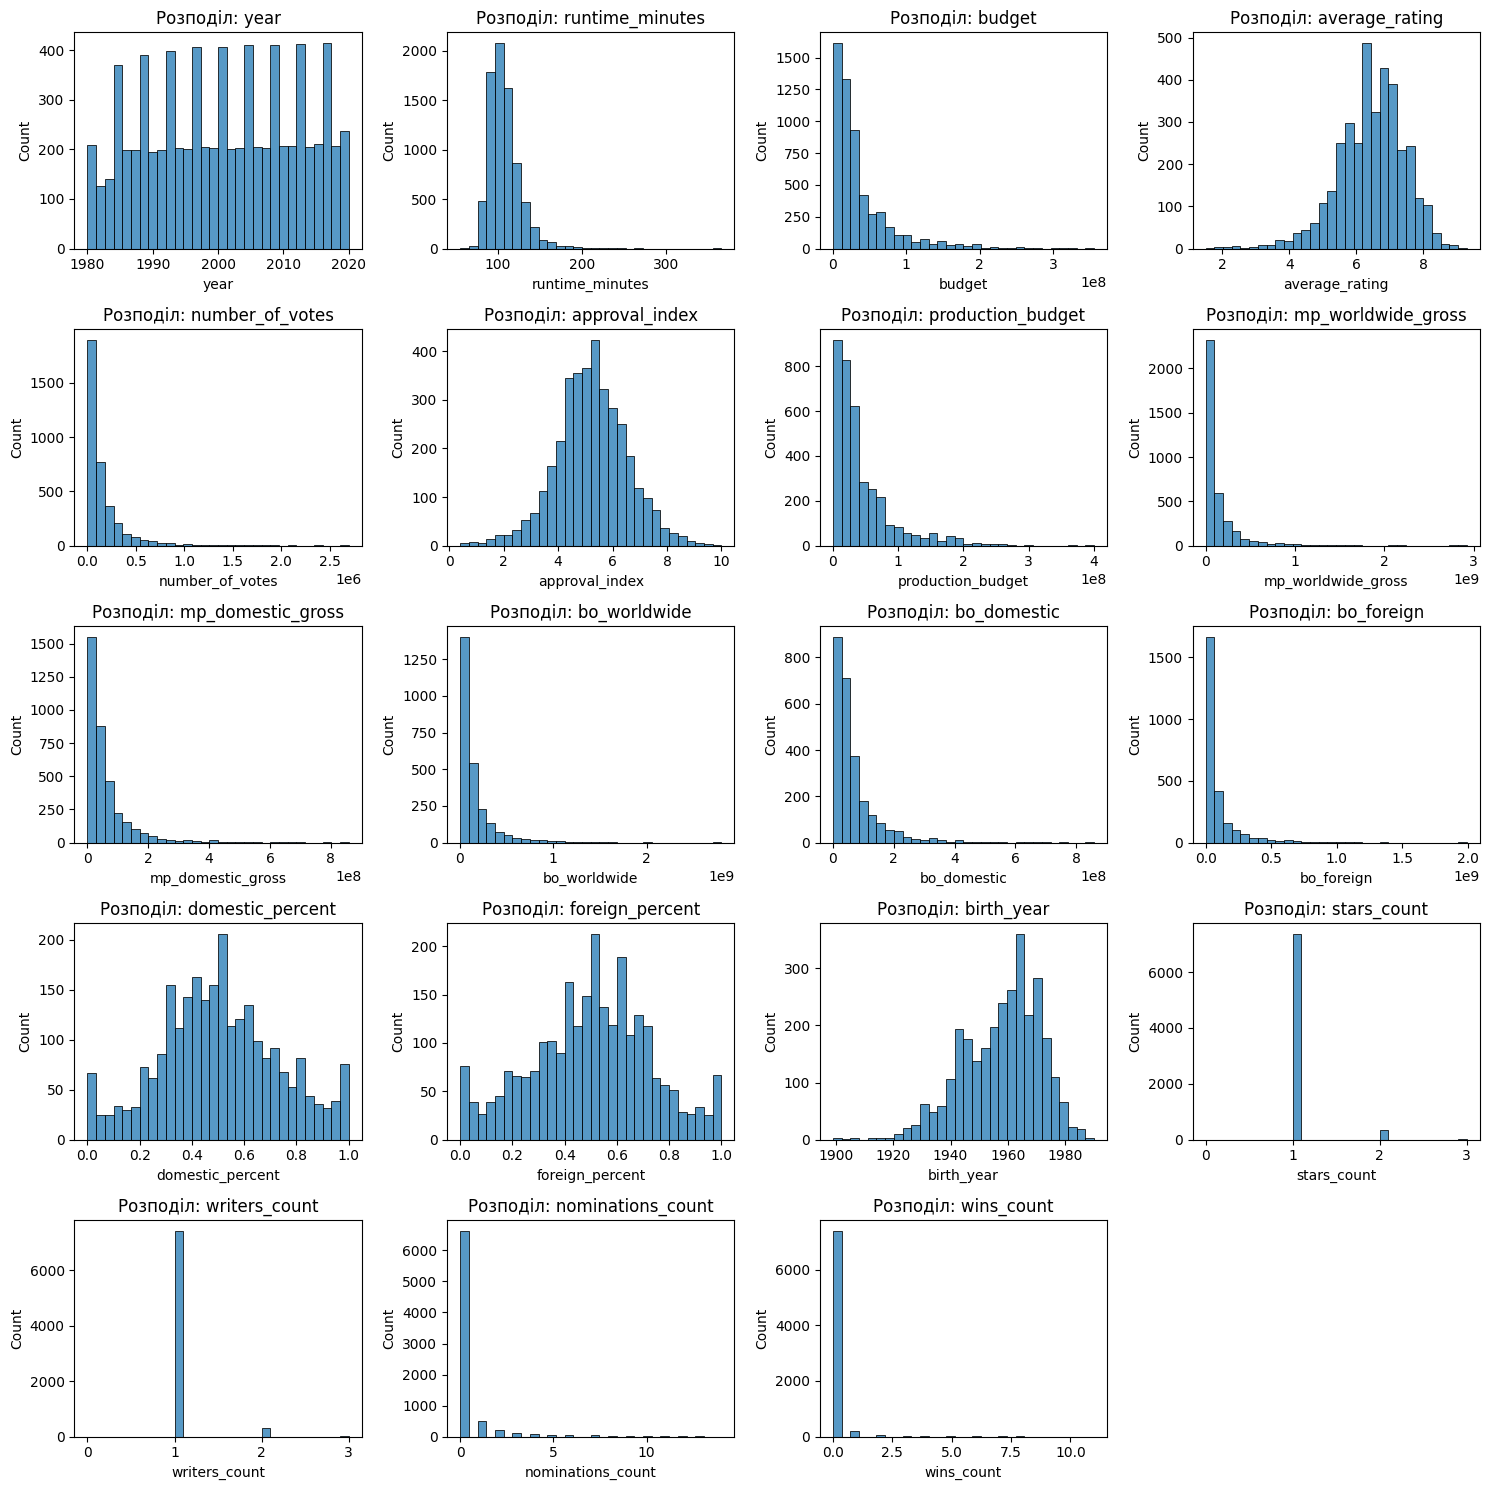

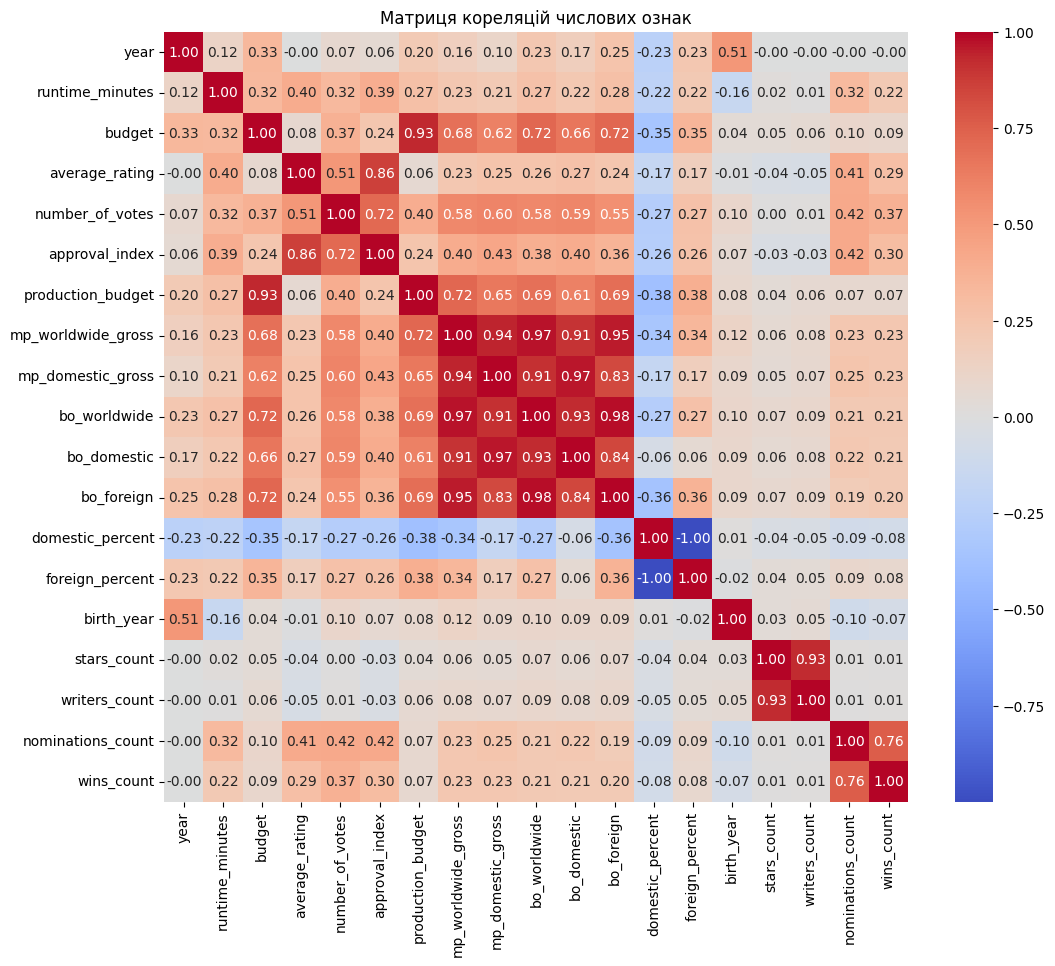

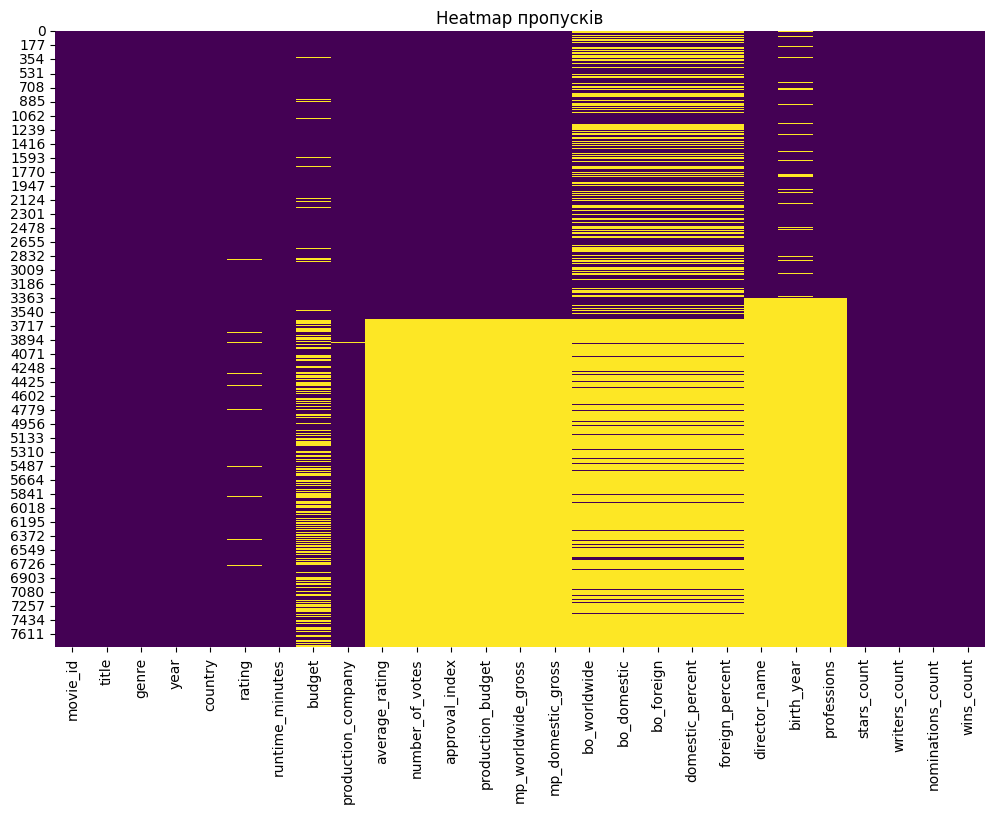

In [183]:
# Аналіз структури датафрейму
print("Інформація про датафрейм:")
print(df.info())
print("\nПерші 5 рядків:")
print(df.head())
print("\nСтатистичні характеристики числових ознак:")
print(df.describe())

# Оцінка пропусків
print("\nВідсоток пропусків у кожному стовпці:")
missing_data = df.isnull().mean() * 100
print(missing_data)

# Визначення категоріальних і числових ознак
categorical_columns = ['genre', 'country', 'rating', 'production_company', 'director_name']
numerical_columns = ['year', 'runtime_minutes', 'budget', 'average_rating', 'number_of_votes', 
                     'approval_index', 'production_budget', 'mp_worldwide_gross', 'mp_domestic_gross', 
                     'bo_worldwide', 'bo_domestic', 'bo_foreign', 'domestic_percent', 'foreign_percent', 
                     'birth_year', 'stars_count', 'writers_count', 'nominations_count', 'wins_count']

# 1. Візуалізації
# Бар-чарт для категоріальних ознак
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 2, i)
    df[col].value_counts().head(10).plot(kind='bar')  # Обмежуємо до 10 категорій
    plt.title(f'Топ-10 значень: {col}')
    plt.xlabel(col)
    plt.ylabel('Кількість')
plt.tight_layout()
plt.show()

# Гістограми для числових ознак
plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(5, 4, i)
    sns.histplot(df[col].dropna(), bins=30)
    plt.title(f'Розподіл: {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

# Теплокарта кореляцій
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матриця кореляцій числових ознак')
plt.show()

# Heatmap пропусків
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap пропусків')
plt.show()

In [184]:
# Відкидання непотрібних полів
columns_to_drop = ['movie_id', 'title', 'stars_count', 'writers_count', 'director_name', 
                   'birth_year', 'professions', 'production_company', 'mp_worldwide_gross', 
                   'mp_domestic_gross', 'budget']
df = df.drop(columns=columns_to_drop)

# Оновлення списків категоріальних і числових ознак
categorical_columns = ['genre', 'country', 'rating']
numerical_columns = ['year', 'runtime_minutes', 'average_rating', 'number_of_votes', 
                     'approval_index', 'production_budget', 'bo_worldwide', 'bo_domestic', 
                     'bo_foreign', 'domestic_percent', 'foreign_percent', 'nominations_count', 'wins_count']

print("Інформація про датафрейм:")
print(df.info())

Інформація про датафрейм:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7776 entries, 0 to 7775
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genre              7776 non-null   object 
 1   year               7776 non-null   int64  
 2   country            7775 non-null   object 
 3   rating             7700 non-null   object 
 4   runtime_minutes    7774 non-null   float64
 5   average_rating     3636 non-null   float64
 6   number_of_votes    3636 non-null   float64
 7   approval_index     3636 non-null   float64
 8   production_budget  3636 non-null   float64
 9   bo_worldwide       2582 non-null   float64
 10  bo_domestic        2582 non-null   float64
 11  bo_foreign         2582 non-null   float64
 12  domestic_percent   2582 non-null   float64
 13  foreign_percent    2582 non-null   float64
 14  nominations_count  7776 non-null   int64  
 15  wins_count         7776 non-null   int64  
dty

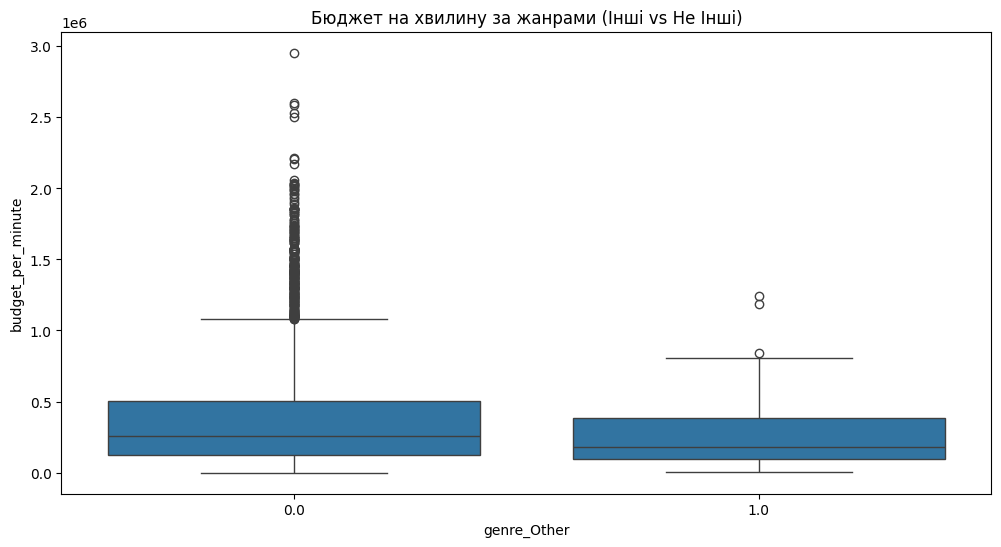

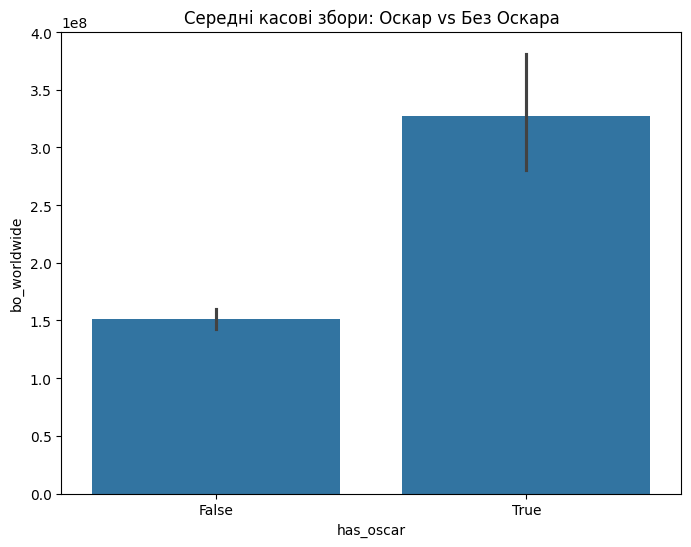

In [185]:
# 1.2 Інжиніринг ознак
# Створення нових ознак
df['budget_per_minute'] = df['production_budget'] / df['runtime_minutes']
df['vote_ratio'] = df['number_of_votes'] / (df['approval_index'] + 1e-5)  # Додаємо малу константу, щоб уникнути ділення на 0
df['mean_gross_by_genre'] = df.groupby('genre')['bo_worldwide'].transform('mean')

# Групування рідкісних категорій у "Other"
for col in categorical_columns:
    value_counts = df[col].value_counts()
    rare_categories = value_counts[value_counts < 50].index
    df[col] = df[col].apply(lambda x: 'Other' if x in rare_categories else x)

# Кодування категоріальних ознак (OneHotEncoder)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_data = ohe.fit_transform(df[categorical_columns])
ohe_df = pd.DataFrame(ohe_data, columns=ohe.get_feature_names_out(categorical_columns))
df = pd.concat([df.drop(categorical_columns, axis=1), ohe_df], axis=1)

# Оновлення числових ознак після кодування
numerical_columns.extend([col for col in df.columns if col.startswith(('genre_', 'country_', 'rating_'))])
numerical_columns = [col for col in numerical_columns if col in df.columns]

# Візуалізації для нових ознак
# Box-plot для budget_per_minute за жанрами
plt.figure(figsize=(12, 6))
sns.boxplot(x='genre_Other', y='budget_per_minute', data=df)
plt.title('Бюджет на хвилину за жанрами (Інші vs Не Інші)')

plt.show()

# Bar-chart середніх касових зборів за наявністю Оскара
df['has_oscar'] = df['wins_count'] > 0
plt.figure(figsize=(8, 6))
sns.barplot(x='has_oscar', y='bo_worldwide', data=df)
plt.title('Середні касові збори: Оскар vs Без Оскара')
plt.show()

Після видалення записів із пропусками в цільових змінних: 2582 записів (було 7776)
Після видалення записів без додаткових числових значень: 2582 записів (було 2582)


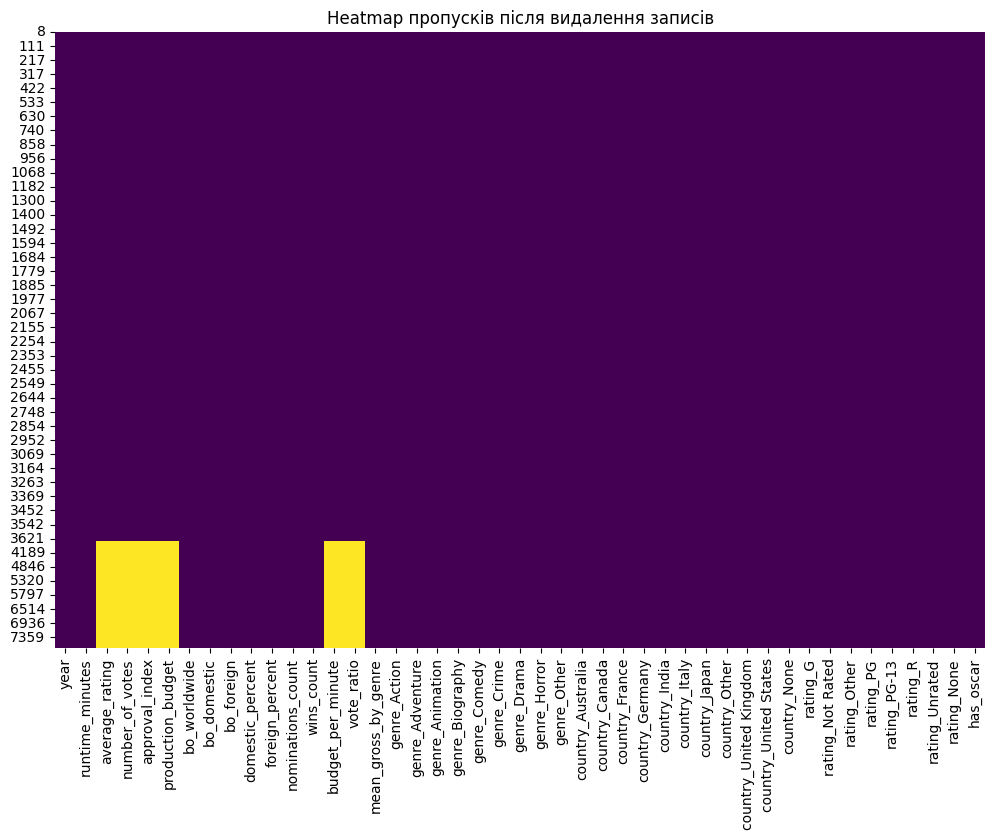

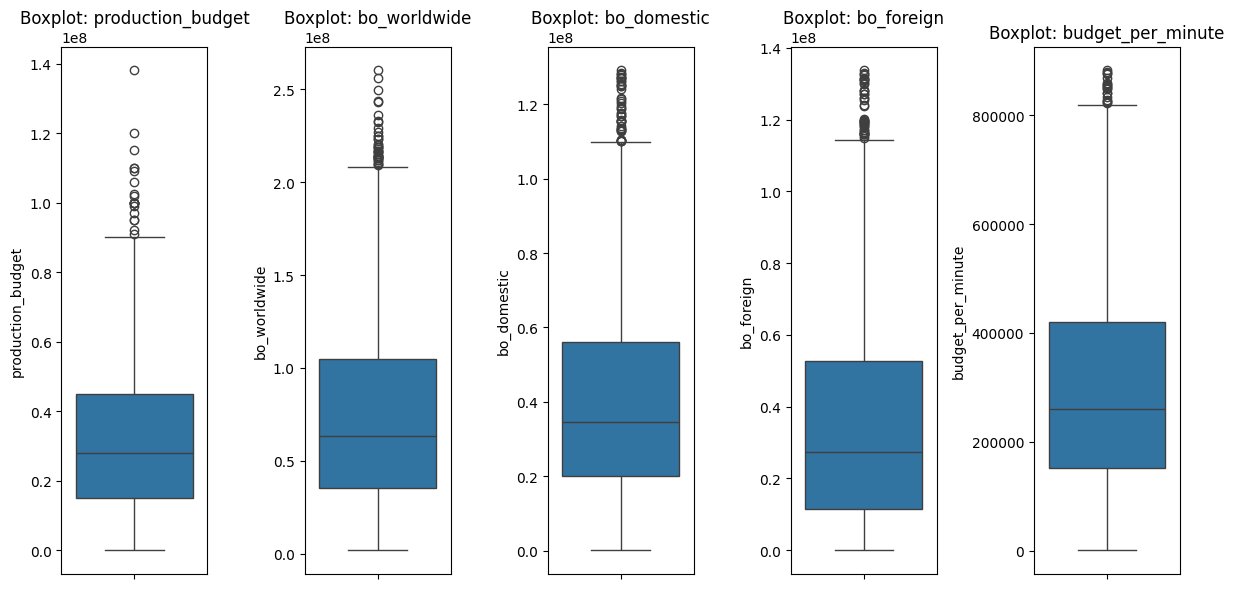

Кількість записів після обробки викидів: 1574


In [186]:

# 1.3 Обробка пропусків і викидів
# Крок 1: Видалення записів із пропусками в цільових змінних
initial_count = len(df)
df = df.dropna(subset=['bo_worldwide', 'wins_count'])
print(f"Після видалення записів із пропусками в цільових змінних: {len(df)} записів (було {initial_count})")

# Крок 2: Видалення записів, де немає хоча б одного додаткового числового значення
additional_numerical_columns = [col for col in numerical_columns if col not in ['bo_worldwide', 'wins_count'] and col in df.columns]
additional_numerical_columns.extend(['budget_per_minute', 'vote_ratio', 'mean_gross_by_genre'])

# Перевірка, чи є хоча б одне не-NaN значення в додаткових числових стовпцях
df['has_numeric'] = df[additional_numerical_columns].notna().any(axis=1)
before_count = len(df)
df = df[df['has_numeric']].drop(columns=['has_numeric'])
print(f"Після видалення записів без додаткових числових значень: {len(df)} записів (було {before_count})")

# Візуалізації після обробки пропусків
# Heatmap пропусків після видалення
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap пропусків після видалення записів')
plt.show()

# Обробка викидів (IQR-метод)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

outlier_columns = ['production_budget', 'bo_worldwide', 'bo_domestic', 'bo_foreign', 'budget_per_minute']
for col in outlier_columns:
    if col in df.columns:
        df = remove_outliers(df, col)

# Boxplot після обробки викидів
plt.figure(figsize=(12, 6))
for i, col in enumerate(outlier_columns, 1):
    if col in df.columns:
        plt.subplot(1, len(outlier_columns), i)
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

print("Кількість записів після обробки викидів:", len(df))

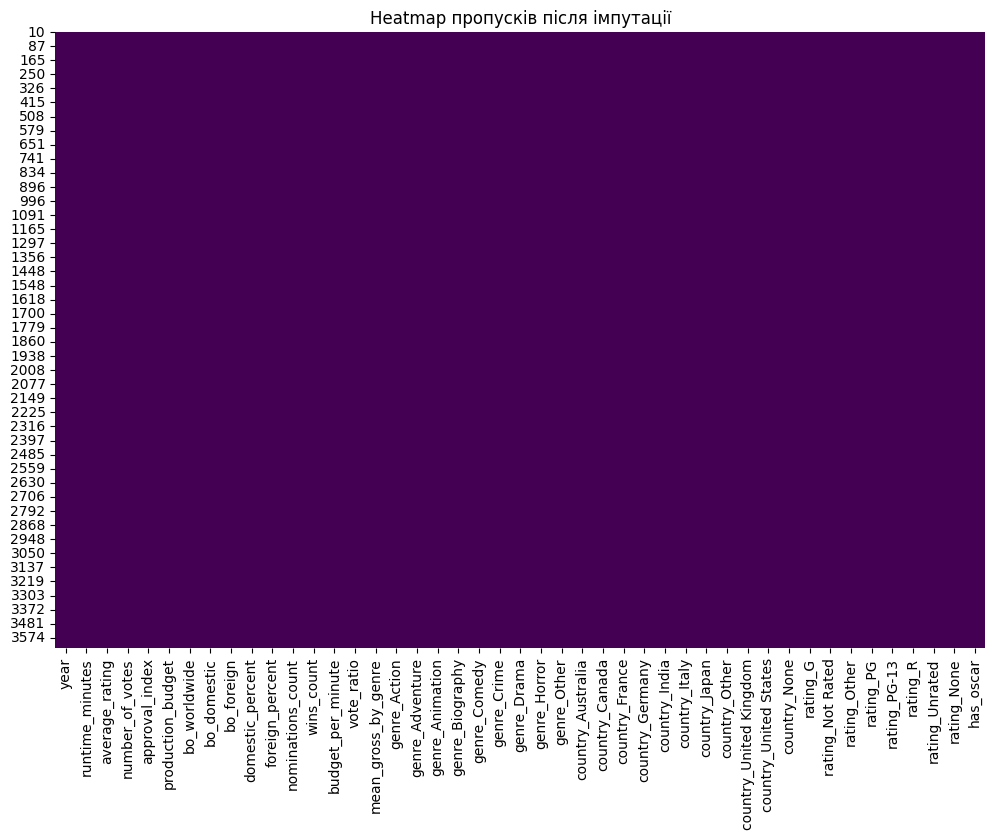

In [187]:
# Візуалізації після обробки
# Heatmap пропусків після імпутації
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap пропусків після імпутації')
plt.show()


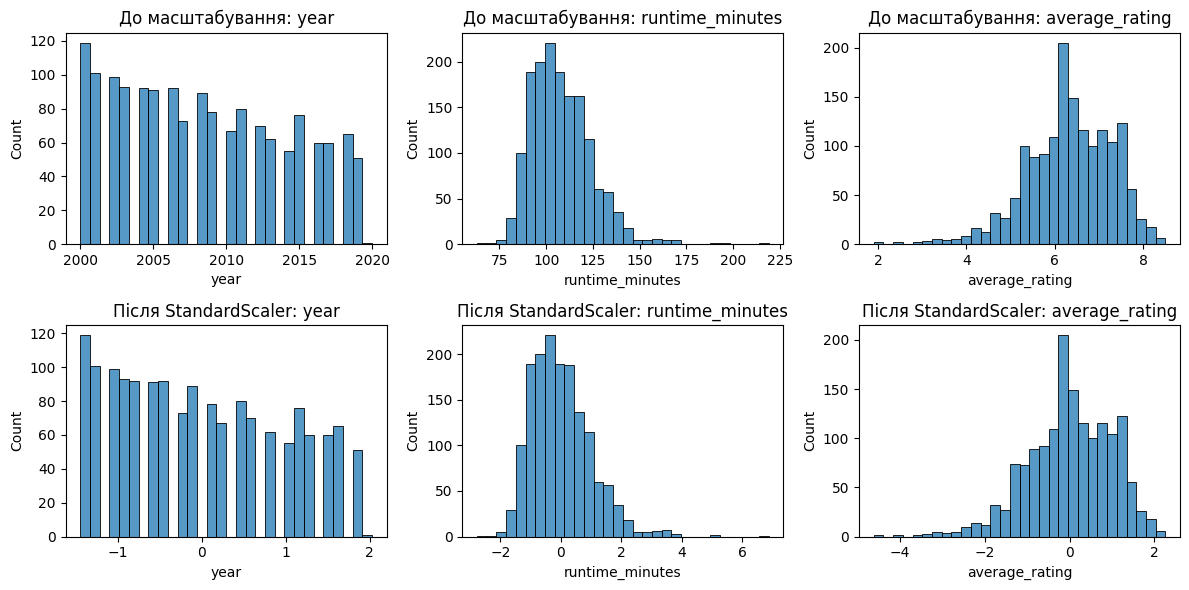

In [188]:
# 1.4 Масштабування числових ознак
# Вибір числових ознак для масштабування
scale_columns = [col for col in df.columns if df[col].dtype in ['float64', 'int64'] and col not in ['bo_worldwide', 'wins_count', 'has_oscar']]

# StandardScaler
scaler_standard = StandardScaler()
df_standard = df.copy()
df_standard[scale_columns] = scaler_standard.fit_transform(df[scale_columns])

# MinMaxScaler
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[scale_columns] = scaler_minmax.fit_transform(df[scale_columns])

# Візуалізації масштабування
# Гістограми до/після масштабування
plt.figure(figsize=(12, 6))
for i, col in enumerate(scale_columns[:3], 1):  # Обмежуємо до 3 для прикладу
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30)
    plt.title(f'До масштабування: {col}')
    plt.subplot(2, 3, i + 3)
    sns.histplot(df_standard[col], bins=30)
    plt.title(f'Після StandardScaler: {col}')
plt.tight_layout()
plt.show()

# Збереження підготовлених даних
df_standard.to_csv('prepared_data_standard.csv', index=False)
df_minmax.to_csv('prepared_data_minmax.csv', index=False)

**2**

In [189]:
from sklearn.model_selection import train_test_split


# Перевірка розміру даних перед розбиттям
print(f"Розмір df_standard: {df_standard.shape}")
print(f"Розмір df_minmax: {df_minmax.shape}")

# 2.1 Розбиття на вибірки
# Визначення ознак (X) і цільових змінних (y) для обох задач
# Для задачі регресії (bo_worldwide)
X_standard_reg = df_standard.drop(columns=['bo_worldwide', 'wins_count', 'has_oscar'])
y_standard_reg = df_standard['bo_worldwide']
X_minmax_reg = df_minmax.drop(columns=['bo_worldwide', 'wins_count', 'has_oscar'])
y_minmax_reg = df_minmax['bo_worldwide']

# Для задачі класифікації (has_oscar)
X_standard_clf = df_standard.drop(columns=['bo_worldwide', 'wins_count', 'has_oscar'])
y_standard_clf = df_standard['has_oscar']
X_minmax_clf = df_minmax.drop(columns=['bo_worldwide', 'wins_count', 'has_oscar'])
y_minmax_clf = df_minmax['has_oscar']

# Розбиття на навчальну (80%) і тестову (20%) вибірки
# Для регресії
X_train_standard_reg, X_test_standard_reg, y_train_standard_reg, y_test_standard_reg = train_test_split(
    X_standard_reg, y_standard_reg, test_size=0.2, random_state=42
)
X_train_minmax_reg, X_test_minmax_reg, y_train_minmax_reg, y_test_minmax_reg = train_test_split(
    X_minmax_reg, y_minmax_reg, test_size=0.2, random_state=42
)

# Для класифікації
X_train_standard_clf, X_test_standard_clf, y_train_standard_clf, y_test_standard_clf = train_test_split(
    X_standard_clf, y_standard_clf, test_size=0.2, random_state=42
)
X_train_minmax_clf, X_test_minmax_clf, y_train_minmax_clf, y_test_minmax_clf = train_test_split(
    X_minmax_clf, y_minmax_clf, test_size=0.2, random_state=42
)

Розмір df_standard: (1574, 45)
Розмір df_minmax: (1574, 45)



Розміри вибірок для регресії (StandardScaler):
Навчальна вибірка: X_train_standard_reg: (1259, 42), y_train_standard_reg: (1259,)
Тестова вибірка: X_test_standard_reg: (315, 42), y_test_standard_reg: (315,)

Розміри вибірок для регресії (MinMaxScaler):
Навчальна вибірка: X_train_minmax_reg: (1259, 42), y_train_minmax_reg: (1259,)
Тестова вибірка: X_test_minmax_reg: (315, 42), y_test_minmax_reg: (315,)

Розміри вибірок для класифікації (StandardScaler):
Навчальна вибірка: X_train_standard_clf: (1259, 42), y_train_standard_clf: (1259,)
Тестова вибірка: X_test_standard_clf: (315, 42), y_test_standard_clf: (315,)

Розміри вибірок для класифікації (MinMaxScaler):
Навчальна вибірка: X_train_minmax_clf: (1259, 42), y_train_minmax_clf: (1259,)
Тестова вибірка: X_test_minmax_clf: (315, 42), y_test_minmax_clf: (315,)


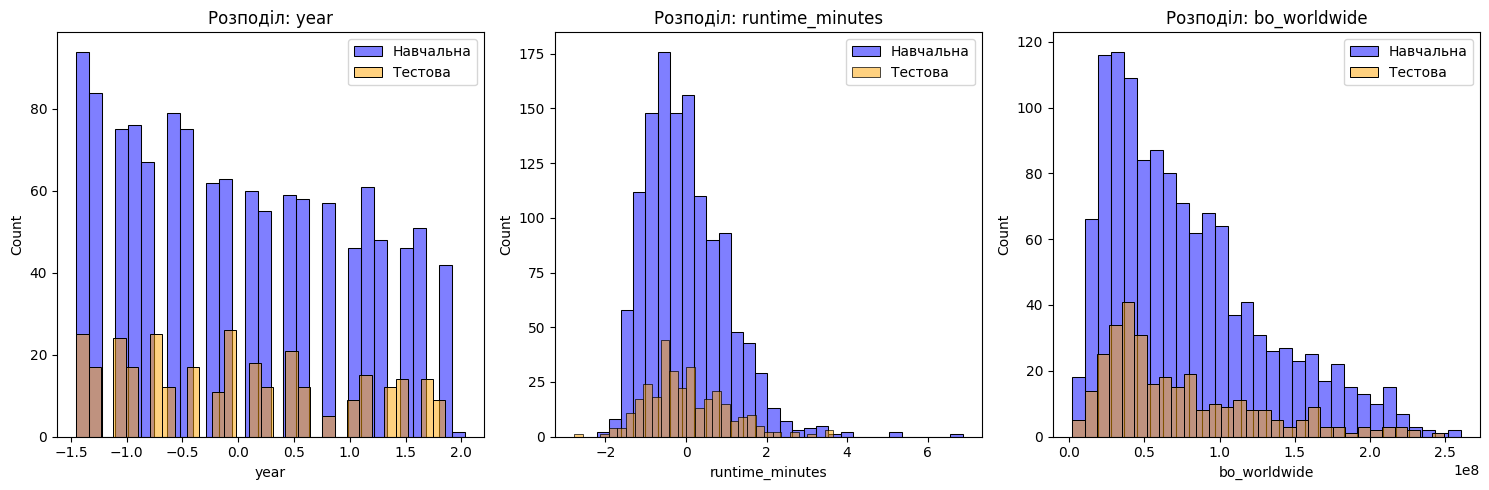

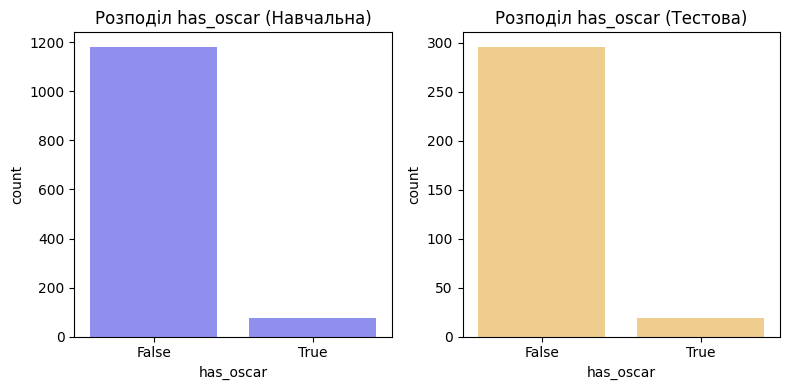

In [190]:
# Виведення розмірів вибірок
print("\nРозміри вибірок для регресії (StandardScaler):")
print(f"Навчальна вибірка: X_train_standard_reg: {X_train_standard_reg.shape}, y_train_standard_reg: {y_train_standard_reg.shape}")
print(f"Тестова вибірка: X_test_standard_reg: {X_test_standard_reg.shape}, y_test_standard_reg: {y_test_standard_reg.shape}")
print("\nРозміри вибірок для регресії (MinMaxScaler):")
print(f"Навчальна вибірка: X_train_minmax_reg: {X_train_minmax_reg.shape}, y_train_minmax_reg: {y_train_minmax_reg.shape}")
print(f"Тестова вибірка: X_test_minmax_reg: {X_test_minmax_reg.shape}, y_test_minmax_reg: {y_test_minmax_reg.shape}")
print("\nРозміри вибірок для класифікації (StandardScaler):")
print(f"Навчальна вибірка: X_train_standard_clf: {X_train_standard_clf.shape}, y_train_standard_clf: {y_train_standard_clf.shape}")
print(f"Тестова вибірка: X_test_standard_clf: {X_test_standard_clf.shape}, y_test_standard_clf: {y_test_standard_clf.shape}")
print("\nРозміри вибірок для класифікації (MinMaxScaler):")
print(f"Навчальна вибірка: X_train_minmax_clf: {X_train_minmax_clf.shape}, y_train_minmax_clf: {y_train_minmax_clf.shape}")
print(f"Тестова вибірка: X_test_minmax_clf: {X_test_minmax_clf.shape}, y_test_minmax_clf: {y_test_minmax_clf.shape}")

# Візуалізації для перевірки розподілів
# Об'єднання X і y для зручності візуалізації
train_standard_reg = X_train_standard_reg.copy()
train_standard_reg['bo_worldwide'] = y_train_standard_reg
test_standard_reg = X_test_standard_reg.copy()
test_standard_reg['bo_worldwide'] = y_test_standard_reg

# Вибір ключових ознак для візуалізації
features_to_plot = ['year', 'runtime_minutes', 'bo_worldwide']

# Гістограми розподілів для регресії (StandardScaler)
plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.histplot(train_standard_reg[col].dropna(), bins=30, color='blue', alpha=0.5, label='Навчальна')
    sns.histplot(test_standard_reg[col].dropna(), bins=30, color='orange', alpha=0.5, label='Тестова')
    plt.title(f'Розподіл: {col}')
    plt.legend()
plt.tight_layout()
plt.show()

# Перевірка розподілу цільової змінної для класифікації (has_oscar)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train_standard_clf, color='blue', alpha=0.5)
plt.title('Розподіл has_oscar (Навчальна)')
plt.subplot(1, 2, 2)
sns.countplot(x=y_test_standard_clf, color='orange', alpha=0.5)
plt.title('Розподіл has_oscar (Тестова)')
plt.tight_layout()
plt.show()

In [191]:
# Збереження вибірок для подальшого використання
# Для регресії
pd.concat([X_train_standard_reg, y_train_standard_reg], axis=1).to_csv('train_standard_reg.csv', index=False)
pd.concat([X_test_standard_reg, y_test_standard_reg], axis=1).to_csv('test_standard_reg.csv', index=False)
pd.concat([X_train_minmax_reg, y_train_minmax_reg], axis=1).to_csv('train_minmax_reg.csv', index=False)
pd.concat([X_test_minmax_reg, y_test_minmax_reg], axis=1).to_csv('test_minmax_reg.csv', index=False)

# Для класифікації
pd.concat([X_train_standard_clf, y_train_standard_clf], axis=1).to_csv('train_standard_clf.csv', index=False)
pd.concat([X_test_standard_clf, y_test_standard_clf], axis=1).to_csv('test_standard_clf.csv', index=False)
pd.concat([X_train_minmax_clf, y_train_minmax_clf], axis=1).to_csv('train_minmax_clf.csv', index=False)
pd.concat([X_test_minmax_clf, y_test_minmax_clf], axis=1).to_csv('test_minmax_clf.csv', index=False)

print("Розбиття на вибірки завершено. Дані збережено у відповідні файли.")

Розбиття на вибірки завершено. Дані збережено у відповідні файли.


**3**

In [192]:
# Кодування цільової змінної для класифікації (якщо потрібно)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


le = LabelEncoder()
y_train_standard_clf = le.fit_transform(y_train_standard_clf)
y_test_standard_clf = le.transform(y_test_standard_clf)
y_train_minmax_clf = le.fit_transform(y_train_minmax_clf)
y_test_minmax_clf = le.transform(y_test_minmax_clf)

# Моделі для регресії
models_reg = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results_reg_standard = {}
results_reg_minmax = {}

for name, model in models_reg.items():
    # Навчання та передбачення для StandardScaler
    model.fit(X_train_standard_reg, y_train_standard_reg)
    y_pred_standard = model.predict(X_test_standard_reg)
    rmse = np.sqrt(mean_squared_error(y_test_standard_reg, y_pred_standard))
    r2 = r2_score(y_test_standard_reg, y_pred_standard)
    results_reg_standard[name] = {'RMSE': rmse, 'R²': r2}
    
    # Навчання та передбачення для MinMaxScaler
    model.fit(X_train_minmax_reg, y_train_minmax_reg)
    y_pred_minmax = model.predict(X_test_minmax_reg)
    rmse = np.sqrt(mean_squared_error(y_test_minmax_reg, y_pred_minmax))
    r2 = r2_score(y_test_minmax_reg, y_pred_minmax)
    results_reg_minmax[name] = {'RMSE': rmse, 'R²': r2}

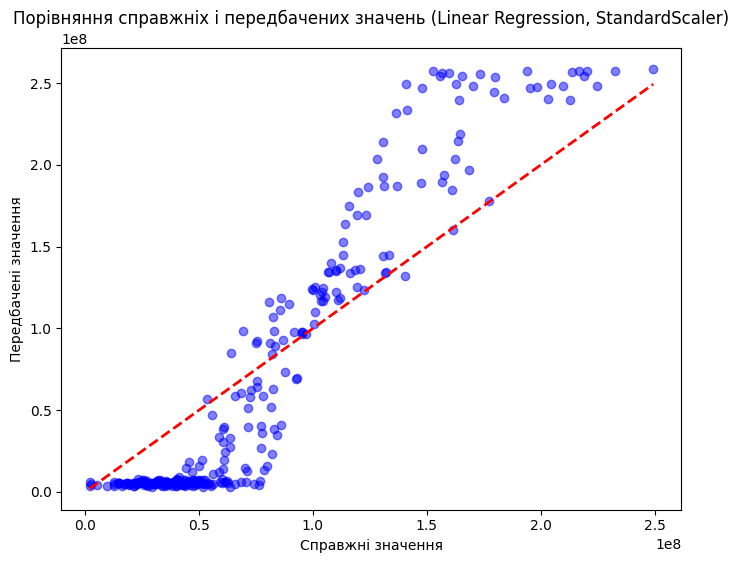

In [193]:
# Візуалізація для регресії (приклад для Linear Regression з StandardScaler)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_standard_reg, model.predict(X_test_standard_reg), color='blue', alpha=0.5)
plt.plot([y_test_standard_reg.min(), y_test_standard_reg.max()], [y_test_standard_reg.min(), y_test_standard_reg.max()], 'r--', lw=2)
plt.xlabel('Справжні значення')
plt.ylabel('Передбачені значення')
plt.title('Порівняння справжніх і передбачених значень (Linear Regression, StandardScaler)')
plt.show()

In [194]:
# Моделі для класифікації
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score



models_clf = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, scale_pos_weight=20, random_state=42)  # Для балансування класів
}

results_clf_standard = {}
results_clf_minmax = {}

for name, model in models_clf.items():
    # Навчання та передбачення для StandardScaler
    model.fit(X_train_standard_clf, y_train_standard_clf)
    y_pred_standard = model.predict(X_test_standard_clf)
    y_pred_proba_standard = model.predict_proba(X_test_standard_clf)[:, 1]
    accuracy = accuracy_score(y_test_standard_clf, y_pred_standard)
    f1 = f1_score(y_test_standard_clf, y_pred_standard)
    roc_auc = roc_auc_score(y_test_standard_clf, y_pred_proba_standard)
    results_clf_standard[name] = {'Accuracy': accuracy, 'F1-score': f1, 'ROC-AUC': roc_auc}
    
    # Навчання та передбачення для MinMaxScaler
    model.fit(X_train_minmax_clf, y_train_minmax_clf)
    y_pred_minmax = model.predict(X_test_minmax_clf)
    y_pred_proba_minmax = model.predict_proba(X_test_minmax_clf)[:, 1]
    accuracy = accuracy_score(y_test_minmax_clf, y_pred_minmax)
    f1 = f1_score(y_test_minmax_clf, y_pred_minmax)
    roc_auc = roc_auc_score(y_test_minmax_clf, y_pred_proba_minmax)
    results_clf_minmax[name] = {'Accuracy': accuracy, 'F1-score': f1, 'ROC-AUC': roc_auc}

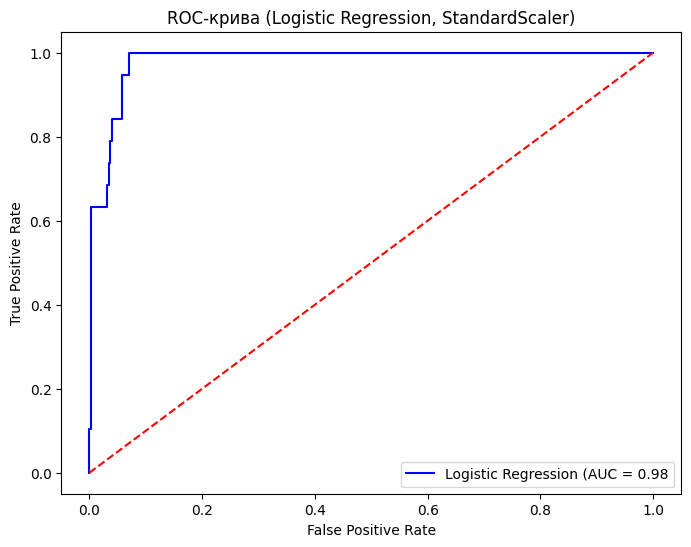


Результати для регресії (StandardScaler):
Linear Regression: RMSE = 89.45, R² = 1.00
Random Forest: RMSE = 1854820.49, R² = 1.00
XGBoost: RMSE = 2314846.07, R² = 1.00

Результати для регресії (MinMaxScaler):
Linear Regression: RMSE = 89.45, R² = 1.00
Random Forest: RMSE = 1856292.35, R² = 1.00
XGBoost: RMSE = 2314846.07, R² = 1.00

Результати для класифікації (StandardScaler):
Logistic Regression: Accuracy = 0.95, F1-score = 0.67, ROC-AUC = 0.98
Random Forest: Accuracy = 0.97, F1-score = 0.70, ROC-AUC = 0.98
XGBoost: Accuracy = 0.96, F1-score = 0.68, ROC-AUC = 0.99

Результати для класифікації (MinMaxScaler):
Logistic Regression: Accuracy = 0.94, F1-score = 0.63, ROC-AUC = 0.98
Random Forest: Accuracy = 0.97, F1-score = 0.70, ROC-AUC = 0.98
XGBoost: Accuracy = 0.96, F1-score = 0.68, ROC-AUC = 0.99


In [195]:
# Візуалізація ROC-кривої для класифікації (приклад для Logistic Regression з StandardScaler)
from sklearn.metrics import roc_curve


fpr, tpr, _ = roc_curve(y_test_standard_clf, model.predict_proba(X_test_standard_clf)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {results_clf_standard["Logistic Regression"]["ROC-AUC"]:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-крива (Logistic Regression, StandardScaler)')
plt.legend()
plt.show()

# Виведення результатів
print("\nРезультати для регресії (StandardScaler):")
for name, metrics in results_reg_standard.items():
    print(f"{name}: RMSE = {metrics['RMSE']:.2f}, R² = {metrics['R²']:.2f}")
print("\nРезультати для регресії (MinMaxScaler):")
for name, metrics in results_reg_minmax.items():
    print(f"{name}: RMSE = {metrics['RMSE']:.2f}, R² = {metrics['R²']:.2f}")
print("\nРезультати для класифікації (StandardScaler):")
for name, metrics in results_clf_standard.items():
    print(f"{name}: Accuracy = {metrics['Accuracy']:.2f}, F1-score = {metrics['F1-score']:.2f}, ROC-AUC = {metrics['ROC-AUC']:.2f}")
print("\nРезультати для класифікації (MinMaxScaler):")
for name, metrics in results_clf_minmax.items():
    print(f"{name}: Accuracy = {metrics['Accuracy']:.2f}, F1-score = {metrics['F1-score']:.2f}, ROC-AUC = {metrics['ROC-AUC']:.2f}")